<img src='https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/tools/frameworks/-/raw/main/img/Standard_banner.png' align='right' width='100%'/>

<a href="../Index.ipynb" target="_blank"><< Index</a>
<br>
<a href="./1_7_OLCI_optical_constituents.ipynb" target="_blank"><< Exploring Sentinel-3 OLCI optical constituents</a>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<a href="1_9_OLCI_iops.ipynb" target="_blank"> Exploring OLCI inherent optical property products >></a>

<font color="#138D75">**Copernicus Marine Training Service**</font> <br>
**Copyright:** 2026 European Union <br>
**License:** MIT <br>
**Authors:** Ben Loveday (EUMETSAT/Innoflair UG), Hayley Evers-King (EUMETSAT)

<html>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-olci"><img src="https://img.shields.io/badge/open-EUMETLAB-E67E22.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://user.eumetsat.int/data/themes/marine"><img src="https://img.shields.io/badge/open-USER PORTAL-154360.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.eumetsat.int%2Feumetlab%2Foceans%2Focean-training%2Fsensors%2Flearn-olci/HEAD?labpath=1_OLCI_introductory%2F1_7_OLCI_optical_constituents.ipynb"><img src="https://mybinder.org/badge_logo.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://jupyterhub.prod.wekeo2.eu/hub/user-redirect/lab/tree/public/wekeo4oceans/learn-olci/1_OLCI_introductory/1_7_OLCI_optical_constituents.ipynb"><img src="https://img.shields.io/badge/launch-WEKEO-1a4696.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://jupyter.central.data.destination-earth.eu/"><img src="https://img.shields.io/badge/launch-DestinE_Stack-2596be.svg"></a></div></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://code.insula.destine.eu/"><img src="https://img.shields.io/badge/launch-DestinE_Insula_Code-f43fd3.svg"></a></div></div>
</html>

<div class="alert alert-block alert-success">
<h3>Learn OLCI: Introductory</h3></div>

<div class="alert alert-block alert-warning">
    
<b>PREREQUISITES </b>
    
**One** of the following modules are prerequisites for this notebook, and will retrieve the data required here.
  - **<a href="./1_1a_OLCI_data_access_Data_Store.ipynb" target="_blank">1_1a_OLCI_data_access_Data_Store.ipynb</a>** if using the Data Store for data access
  - **<a href="./1_1b_OLCI_data_access_WEkEO_HDA.ipynb" target="_blank">1_1b_OLCI_data_access_WEkEO_HDA.ipynb</a>** if using WEkEO for data access
  - **<a href="./1_1c_OLCI_data_access_DEDL_HDA.ipynb" target="_blank">1_1b_OLCI_data_access_DEDL_HDA.ipynb</a>** if using DestinE for data access
    
</div>

<hr>

<div class="alert alert-block alert-danger">
In early 2026, EUMETSAT introduced a new operational processor for Sentinel-3 OLCI products; known as baseline collection BC004. This processor introduced a new atmospheric correction approach, a new chlorophyll algorithm, BRDF correction and an expanded product suite. You can find full information on the <b><a href="https://user.eumetsat.int/news-events/news/new-sentinel-3-olci-level-2-water-processing" target="_blank">EUMETSAT User Portal</a></b>. This processor introduces significant discontinuities with both the previous operational level 2 processor (BC003) and the current best available reprocessing (also BC003). In these modules, you can find notebooks suitable for working with both BC003 and BC004 level 2 products. Please take care to select the notebook that is appropriate for your baseline of interest. Level 1b products are not affected.
</div>

# Exploring and visualising Sentinel-3 OLCI fluorescence products (BC004)

### Data used

| Dataset | EUMETSAT collection ID| EUMETSAT collection<br>description | WEkEO dataset ID | WEkEO description |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|
| Sentinel-3 OLCI level 2 full resolution (operational) | EO:EUM:DAT:0407 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:OL_2_WFR___NTC" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:OL_2_WFR___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3AOL_2_WFR___" target="_blank">Description</a> |

### Learning outcomes

At the end of this notebook you will know;
* How to use the fluorescence products from OLCI baseline collection 004
* How to plot these constituents data on a map, with appropriate flags applied

### Outline

Fluorescence peak height (FPH) is an ocean colour product that provides information on the fluorescence signal associated with chlorophyll-a. When phytoplankton absorb sunlight for photosynthesis, not all of the absorbed energy is used in photosynthetic processes. A small proportion is re-emitted as fluorescence at longer wavelengths, producing a characteristic signal in the red and near-infrared region of the reflectance spectrum.

The spectral bands available on OLCI allow this fluorescence signal to be detected as a peak in reflectance around 681 nm, relative to the surrounding wavelengths. The fluorescence peak height is calculated by estimating the height of this feature above a baseline defined using neighbouring spectral bands. As a result, FPH provides a measure of the prominence of the fluorescence feature in the observed spectrum rather than a direct estimate of chlorophyll-a concentration.

The strength of the fluorescence signal is influenced by several factors, including phytoplankton biomass, species composition, physiological state, and the amount of light available for photosynthesis. The observed signal may also be affected by other optically active constituents and by atmospheric correction uncertainties. Consequently, the relationship between FPH and chlorophyll-a concentration is not always straightforward.

FPH can nevertheless provide useful complementary information to standard chlorophyll-a products, particularly in waters with high phytoplankton concentrations where conventional blue-to-green chlorophyll algorithms may be less effective. It can also be useful for identifying and examining intense phytoplankton blooms and their spatial variability.

This notebook will show you how to work with the new fluorescence peak height (FPH) variable, and will provide links to further information on the algorithm and its validation.

<div class="alert alert-info" role="alert">

## <a id='TOC_TOP_1_8'></a>Contents

</div>

 1. [Importing dependencies](#IMP_1_8)
 1. [The OLCI fluorescence peak height algorithm and product](#The-OLCI-fluorescence-peak-height-algorithm-and-product)
 1. [Reading OLCI fluorescence products](#Reading-OLCI-fluorescence-products)
 1. [Understanding and applying flags](#Understanding-and-applying-flags)

<hr>

<div class="alert alert-info" role="alert">

## <a id='IMP_1_8'></a>Importing dependencies
[Back to top](#TOC_TOP_1_8)

</div>

We begin by importing all of the libraries that we need to run this notebook. If you have built your python using the environment file provided in this repository, then you should have everything you need. For more information on building environment, please see the repository **<a href="../README.md" target="_blank">README</a>**.

In [14]:
import cartopy.crs as ccrs          # a library that support mapping
import glob                         # a library that aids in searching for files
import matplotlib.pyplot as plt     # a library that support plotting
import matplotlib.ticker as mticker # a library that extends plotting support
import numpy as np                  # a library that provides support for array-based mathematics
import os                           # a library that allows us access to basic operating system commands like making directories
import warnings                     # a library that helps us manage warnings
import xarray as xr                 # a library that supports the use of multi-dimensional arrays in Python
import eumartools                   # a EUMETSAT library that support working with Sentinel-3 products
warnings.filterwarnings('ignore')

# set plot font size
plt.rcParams.update({'font.size': 12})

<div class="alert alert-info" role="alert">

## The OLCI fluorescence peak height (FPH) algorithm and product
[Back to top](#TOC_TOP_1_8)

</div>

<div class="alert alert-block alert-danger">
<b>IMPORTANT</b>: Sentinel-3 OLCI level 2 fluorescence products are only available from baseline collection 004 (BC004) onwards.</b>
</div>

Fluorescence peak height is provided in the OLCI Level-2 products. The product is called:

* FPH

and can be found in the `fluorescence.nc` file.

The fluorescence peak height (FPH) provides a measure of the prominence of the chlorophyll fluorescence feature in the red region of the reflectance spectrum. It is derived using OLCI spectral bands around the chlorophyll fluorescence emission feature and represents the height of the observed signal relative to a baseline defined using neighbouring wavelengths.

FPH is not a direct estimate of chlorophyll-a concentration. Instead, it provides an indication of the strength of the fluorescence feature observed by the satellite. The magnitude of this signal can be influenced by phytoplankton biomass, composition and physiological state, as well as environmental conditions and other optically active constituents in the water.

The FPH product can therefore provide complementary information to chlorophyll-a concentration products and can be particularly useful for examining waters with elevated phytoplankton biomass and identifying prominent phytoplankton bloom features.

You can find additional information about Sentinel-3 OLCI level 2 products in the <a href="https://user.eumetsat.int/resources/user-guides/sentinel-3-ocean-colour-level-2-data-guide" target="_blank">Sentinel-3 ocean colour level 2 data guide</a> and the Sentinel-3 OLCI level 2 baseline collection 004 <a href="https://user.eumetsat.int/s3/ope-eup-strapi-media/S3_PN_OLCI_L2_M_004_00_Sentinel_3_Product_Notice_OLCI_Level_2_Water_v1_cfa434a623.pdf" target="_blank">product notice</a>.

<div class="alert alert-info" role="alert">

## Reading OLCI fluorescence products
[Back to top](#TOC_TOP_1_8)

</div>

To begin with, we'll create paths that point to the location of our data of interest.

In [2]:
SAFE_directory = glob.glob(os.path.join(os.getcwd(), 'products', '*WFR*004*'))[0]

Next we'll set a parameter to reduce the resolution of the data we are working with. For analyses you would not want to do this, but it will help us to visualise our data much faster in the context of this tutorial notebook.

In [3]:
grid_reduce = 5

Then, we'll open our latitude and longitude grid, subsampling by `grid_reduce`.

In [4]:
geo_file = os.path.join(SAFE_directory,'geo_coordinates.nc')
geo_fid = xr.open_dataset(geo_file)
lon = geo_fid.longitude.data[::grid_reduce, ::grid_reduce]
lat = geo_fid.latitude.data[::grid_reduce, ::grid_reduce]
geo_fid.close()

We'll also open our fluorescence product.

In [5]:
band_vars = xr.open_mfdataset(glob.glob(os.path.join(SAFE_directory,'fluorescence.nc')))

<div class="alert alert-info" role="alert">

## Understanding and applying flags
[Back to top](#TOC_TOP_1_8)

</div>

As well as the data and the geocoordinates, to plot geophysical products derived from OLCI properly, we also need to extract and apply the relevant quality flags. Below you can see that the flags are extracted from the wqsf netcdf file. If we print out the flags and their associated bit values, you can get an idea about what they represent, and how to access each individual one.

In [6]:
flag_file = os.path.join(SAFE_directory,'wqsf.nc')
flag_vars = xr.open_dataset(flag_file)
band_vars["WQSF"] = flag_vars["WQSF"]

We'll use a quick function from the `eumartools` library that allows us to read in the flag information simply by supplying the name. For our recommendations on which flags to apply you should also consult the <a href="https://user.eumetsat.int/resources/user-guides/sentinel-3-olci-ocean-colour-processing-baseline" target="_blank">OLCI level 2 product notices</a> for the relevant processing baseline.

In [7]:
# reading masks: example land
land_mask = eumartools.flag_mask(flag_file, 'WQSF', ['LAND'])
land_mask = land_mask.astype(float)[::grid_reduce, ::grid_reduce]
land_mask[land_mask == 0.0] = np.nan

# reading masks: example cloud
cloud_mask = eumartools.flag_mask(flag_file, 'WQSF', ['CLOUD', 'CLOUD_AMBIGUOUS', 'CLOUD_MARGIN'])
cloud_mask = cloud_mask.astype(float)[::grid_reduce, ::grid_reduce]
cloud_mask[cloud_mask == 0.0] = np.nan

We'll create a combined mask by reading in all the flags that are relevant for the FPH product. These are the recommended flags provided by EUMETSAT.

In [8]:
# reading masks: all flags BAC recommended
FPH_mask = eumartools.flag_mask(flag_file, 'WQSF', ['LAND', 'CLOUD', 'CLOUD_AMBIGUOUS', 'CLOUD_MARGIN', 
                                                    'INVALID', 'COSMETIC', 'SATURATED', 'SUSPECT',
                                                    'HISOLZEN', 'UNCORR_GLINT', 'SNOW_ICE', 'AC_FAIL',
                                                    'WHITECAPS', 'ADJAC', 'RWNEG_O2', 'RWNEG_O3',
                                                    'RWNEG_O4', 'RWNEG_O5', 'RWNEG_O6', 'RWNEG_O7', 'RWNEG_O8'])
FPH_mask = FPH_mask.astype(float)[::grid_reduce, ::grid_reduce]
FPH_mask[FPH_mask == 0.0] = np.nan

<div class="alert alert-info" role="alert">

## Plotting fluorescence
[Back to top](#TOC_TOP_1_8)

</div>

Now that we've read in both the data we're interested in, and the flags to creat a mask, we can plot the data on a map...

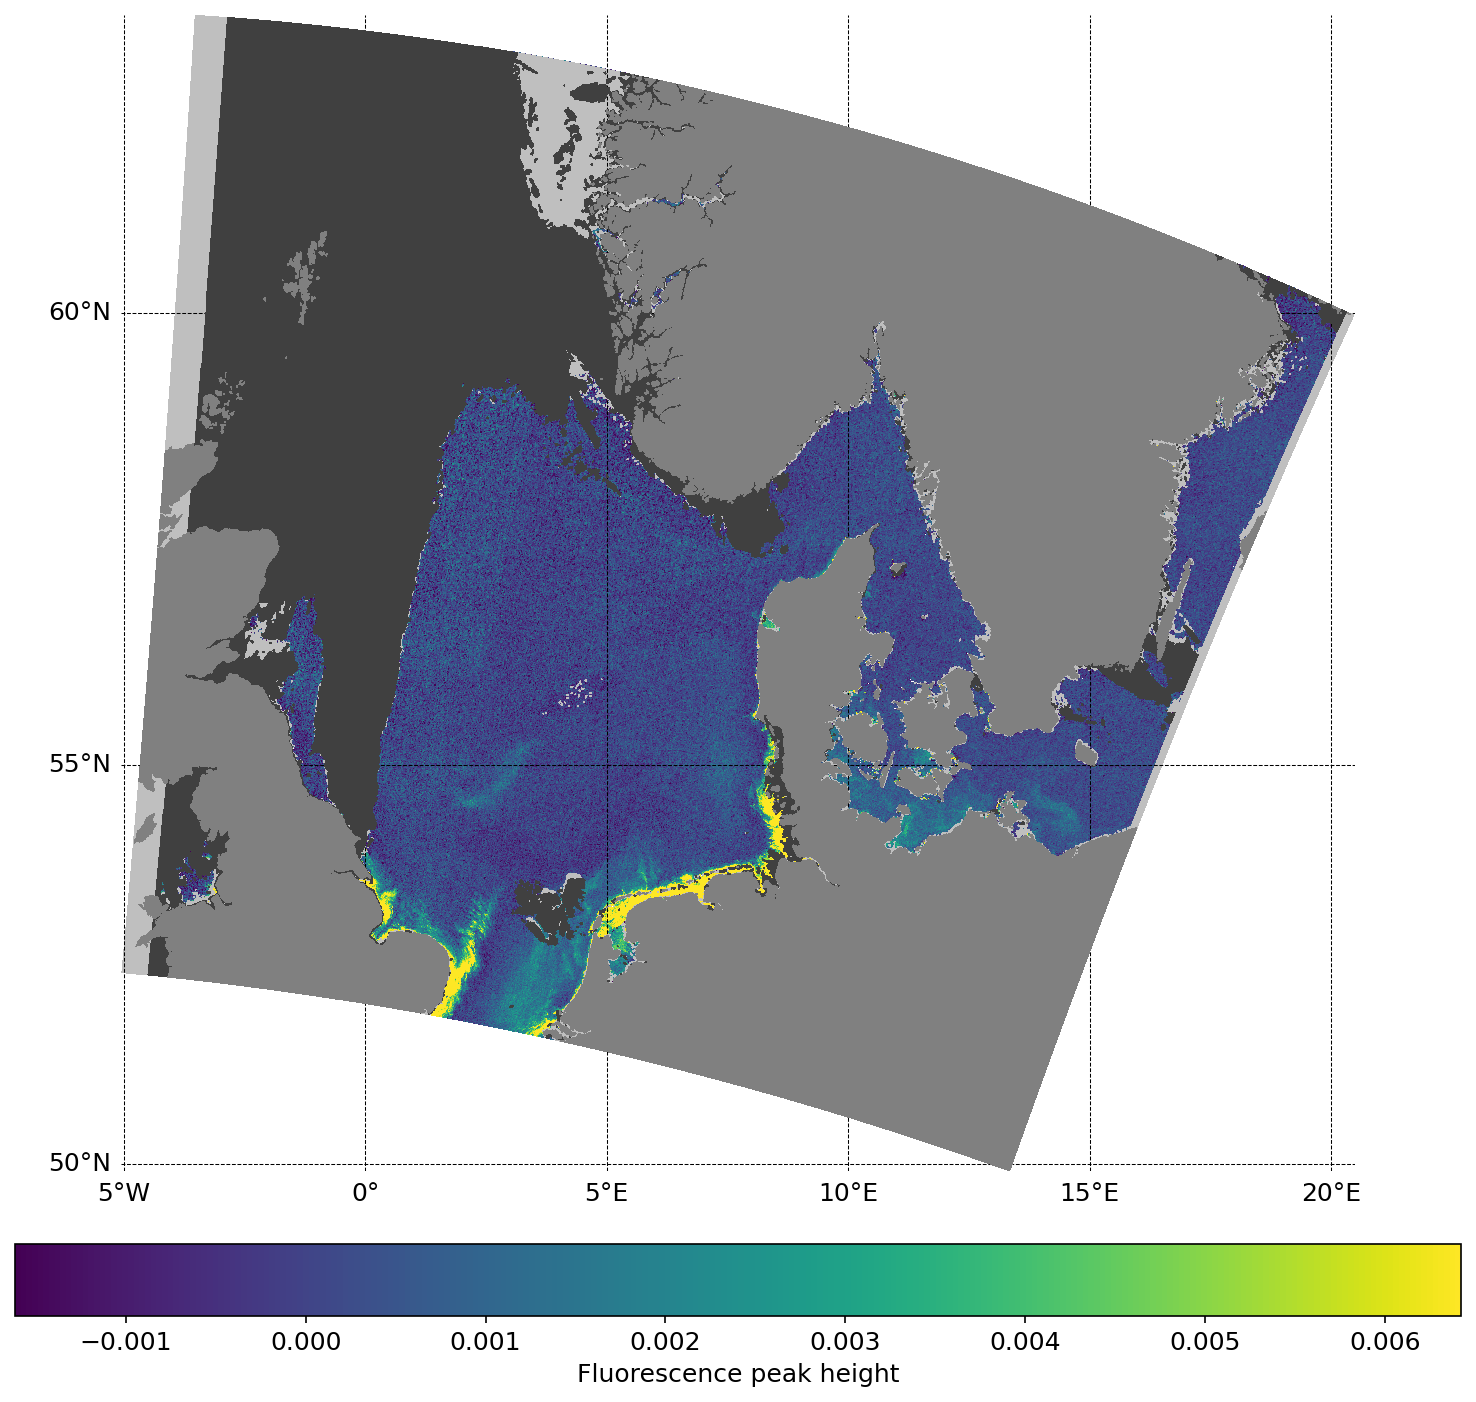

In [13]:
fig = plt.figure(figsize=(10, 10), dpi=150)
m = plt.subplot(projection=ccrs.Mercator())

vmin, vmax = np.nanpercentile(band_vars["FPH"][::grid_reduce, ::grid_reduce], [2, 98])

p1 = m.pcolormesh(lon, lat, band_vars["FPH"][::grid_reduce, ::grid_reduce], transform=ccrs.PlateCarree(), 
                   cmap="viridis", vmin=vmin, vmax=vmax, zorder=1)

m.contourf(lon, lat, FPH_mask, levels=[0,1], transform=ccrs.PlateCarree(), colors='0.75', zorder=2)
m.contourf(lon, lat, cloud_mask, levels=[0,1], transform=ccrs.PlateCarree(), colors='0.25', zorder=3)
m.contourf(lon, lat, land_mask, levels=[0,1], transform=ccrs.PlateCarree(), colors='0.5', zorder=4)

# Embellish with gridlines
g1 = m.gridlines(draw_labels = True, zorder=20, color='0.0', linestyle='--',linewidth=0.5)
g1.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))
g1.ylocator = mticker.FixedLocator(np.arange(-90, 90, 5))
g1.top_labels = False
g1.right_labels = False
g1.xlabel_style = {'color': 'black'}
g1.ylabel_style = {'color': 'black'}
m.set(facecolor = "1.0")
m.axis('off')

cbar = fig.colorbar(p1, location='bottom', pad=0.05)
cbar.set_label('Fluorescence peak height')

plt.tight_layout()
plt.savefig('1_8_OLCI_FPH.png', bbox_inches='tight')

<div class="alert alert-info" role="alert">

## Applying your knowledge
[Back to top](#TOC_TOP_1_8)

</div>

### What to try next?

* Try to adapt the above to a different area and see how the optical constituents differ for your region of interest

## <tr>
[Back to top](#TOC_TOP_1_8)

<hr>
<a href="../Index.ipynb" target="_blank"><< Index</a>
<br>
<a href="./1_7_OLCI_optical_constituents.ipynb" target="_blank"><< Exploring Sentinel-3 OLCI optical constituents</a>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<a href="1_9_OLCI_iops.ipynb" target="_blank"> Exploring OLCI inherent optical property products >></a>
<hr>
<a href="https://gitlab.eumetsat.int/eumetlab/ocean" target="_blank">View on GitLab</a> | <a href="https://training.eumetsat.int/" target="_blank">EUMETSAT Training</a> | <a href=mailto:ops@eumetsat.int target="_blank">Contact helpdesk for support </a> | <a href=mailto:training@eumetsat.int target="_blank">Contact our training team to collaborate on and reuse this material</a></span></p>